In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_lnn_memory_impact(
    n_neuron=256,
    input_dim=19,                  
    
    # --- 1. Baseline: FP32 (Software / GPU Standard) ---
    fp32_bits=32,                   
    
    # --- 2. Competitor: INT8 (Standard Edge NPU) ---
    int8_bits=8,                   
    # CAM/LUTの設定
    prop_cam_in_bits=8,            
    prop_lut_out_bits=8,          
    prop_processor_sram_bits=8,          
    prop_processor_rram_bits=8,            
    prop_weight_bits=8,
    block=None,
    bit_range=[1,2,3,4,5,6,7,8],                          
):
    """
    FP32, INT8, 提案手法の3つのメモリ容量を比較するシミュレーション
    各量子化パラメータはリストでも単一値でも可
    """
    if block is not None:
        if block=="CAM":
            prop_cam_in_bits = bit_range
        elif block=="LUT":
            prop_lut_out_bits = bit_range
        elif block=="SRAM":
            prop_processor_sram_bits = bit_range
        elif block=="RRAM":
            prop_processor_rram_bits = bit_range
        elif block=="Weight":
            prop_weight_bits = bit_range    
        else:
            raise ValueError("Invalid block name for sweeping bits.")
    
    results = []
    
    # 各パラメータがリストかどうか判定し、リスト化
    def ensure_list(x):
        return x if isinstance(x, (list, tuple, np.ndarray)) else [x]

    cam_bits_list = ensure_list(prop_cam_in_bits)
    lut_bits_list = ensure_list(prop_lut_out_bits)
    proc_sram_bits_list = ensure_list(prop_processor_sram_bits)
    proc_rram_bits_list = ensure_list(prop_processor_rram_bits)
    weight_bits_list = ensure_list(prop_weight_bits)

    for cam_bits in cam_bits_list:
        for lut_bits in lut_bits_list:
            for proc_sram_bits in proc_sram_bits_list:
                for proc_rram_bits in proc_rram_bits_list:
                    for weight_bits in weight_bits_list:
                        # 共通パラメータ: 重みの総数
                        total_params_weight = (n_neuron + input_dim) * n_neuron
                        
                        # 1. Baseline: FP32 (Full Precision)
                        size_fp32_mvm = total_params_weight * fp32_bits
                        total_fp32_kbits = size_fp32_mvm / 1000
                        
                        # 2. Competitor: INT8 (Standard Quantization)
                        size_int8_mvm = total_params_weight * int8_bits * 2
                        size_int8_cam = (2**int8_bits) * int8_bits # CAM overhead
                        size_int8_lut = n_neuron * (2**int8_bits) * int8_bits # LUT overhead
                        size_int8_processor = 4 * n_neuron * int8_bits # その他プロセッサオーバーヘッド
                        total_int8_kbits = (size_int8_mvm + size_int8_cam + size_int8_lut + size_int8_processor) / 1000
                        
                        # 3. Proposed (Mixed Precision & Architecture)
                        size_prop_mvm = total_params_weight * weight_bits * 2
                        entries = 2 ** cam_bits
                        size_prop_cam = entries * cam_bits # Key
                        size_prop_lut = n_neuron * entries * lut_bits # Value
                        size_prop_processor = n_neuron * (3 * proc_rram_bits + proc_sram_bits) # その他プロセッサオーバーヘッド
                        total_prop_kbits = (size_prop_mvm + size_prop_cam + size_prop_lut + size_prop_processor) / 1000
                        
                        swept_bit = None
                        if block == "CAM":
                            swept_bit = cam_bits
                        elif block == "LUT":
                            swept_bit = lut_bits
                        elif block == "SRAM":
                            swept_bit = proc_sram_bits
                        elif block == "RRAM":
                            swept_bit = proc_rram_bits
                        elif block == "Weight":
                            swept_bit = weight_bits

                        # 削減率の計算 (vs FP32)
                        reduction_vs_fp32 = (total_prop_kbits / total_fp32_kbits) * 100
                        reduction_vs_int8 = (total_prop_kbits / total_int8_kbits) * 100
                        
                        results.append({
                            "bit": swept_bit,
                            "Neuron Count": n_neuron,
                            "CAM Size": size_prop_cam,
                            "LUT Size": size_prop_lut,
                            "Processor Size": size_prop_processor,
                            "MVM Size": size_prop_mvm,
                            "FP32 Size (kbits)": total_fp32_kbits,
                            "INT8 Size (kbits)": total_int8_kbits,
                            "Ours Size (kbits)": total_prop_kbits,
                            "Red. vs FP32 (%)": reduction_vs_fp32,
                            "Red. vs INT8 (%)": reduction_vs_int8,
                        })
    return pd.DataFrame(results)

In [12]:
def plot_quantization_results(block, bit_range):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import glob
    import re
    import pandas as pd

    # =====================
    # Config
    # =====================
    units = [64, 128, 256]
    base_path = f"/work/robomimic/csv/result/quantize/LNN_standardization/{block}"
    TOP_K = 10

    sns.set_style("white")

    custom_colors = {
        "u64": "#351fb4",
        "u128": "#06a600",
        "u256": "#d62728",
    }
    markers = {
        "u64": "s",
        "u128": "o",
        "u256": "^",
    }

    TICK_SIZE = 25

    # =====================
    # Load success-rate CSVs
    # =====================
    def extract_bit(path):
        m = re.search(r"([0-9.]+)bit.csv", path)
        return float(m.group(1)) if m else None

    results = []

    for unit in units:
        files = glob.glob(f"{base_path}/unit{unit}/*.csv")

        for f in files:
            bit = extract_bit(f)
            if bit is None:
                continue

            # ★ 1bitファイルを除外（ここでスキップする）
            if float(bit) == 1.0:
                continue

            df = pd.read_csv(f)
            topk = df.nlargest(TOP_K, "success_rate")

            results.append({
                "unit": unit,
                "bit": bit,
                "mean_success": topk["success_rate"].mean(),
                "std_success": topk["success_rate"].std()
            })

    results_df = pd.DataFrame(results)

    # =====================
    # Memory analysis
    # =====================
    df_mem = analyze_lnn_memory_impact(block=block, bit_range=bit_range)
    df_mem = df_mem[["bit", "Ours Size (kbits)","Red. vs INT8 (%)"]].copy()
    df_mem["bit"] = df_mem["bit"].astype(float)
    df_mem = df_mem.sort_values("bit").reset_index(drop=True)

    merged = results_df.merge(df_mem, on="bit", how="left").sort_values(["unit", "bit"])
    merged["diff_success_rate"] = merged.groupby("unit")["mean_success"].diff()
    merged["diff_memory_kbits"] = merged.groupby("unit")["Red. vs INT8 (%)"].diff()
    merged["gain_per_kbit"] = merged["diff_success_rate"] / merged["diff_memory_kbits"] * 100

    # ==== きれいに出力（表形式）====
    summary = merged.copy()
    summary["mean_success_%"] = summary["mean_success"] * 100.0
    summary["diff_success_pp"] = summary["diff_success_rate"] * 100.0  # 変化量をppで見せる
    summary["diff_red_vs_int8_pp"] = summary["diff_memory_kbits"]       # (Red. vs INT8) の差分 = pp

    summary = summary[[
        "unit",
        "bit",
        "mean_success_%",
        "diff_success_pp",
        "Red. vs INT8 (%)",
        "diff_red_vs_int8_pp",
        "gain_per_kbit",
    ]].sort_values(["unit", "bit"]).reset_index(drop=True)

    summary = summary.round({
        "mean_success_%": 2,
        "diff_success_pp": 2,
        "Red. vs INT8 (%)": 2,
        "diff_red_vs_int8_pp": 2,
        "gain_per_kbit": 4,
    })

    print(summary.to_string(index=False))

    # =====================
    # Figure
    # =====================
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    # =====================
    # Left axis: Success Rate
    # =====================
    for unit in units:
        df_u = (
            results_df[results_df["unit"] == unit]
            .sort_values("bit")
        )

        ax1.plot(
            df_u["bit"],
            df_u["mean_success"] * 100,
            color=custom_colors[f"u{unit}"],
            linewidth=3,
            zorder=5,
        )

        ax1.scatter(
            df_u["bit"],
            df_u["mean_success"] * 100,
            marker=markers[f"u{unit}"],
            s=180,
            facecolors="white",
            edgecolors=custom_colors[f"u{unit}"],
            linewidths=3,
            zorder=6,
        )

        ax1.errorbar(
            df_u["bit"],
            df_u["mean_success"] * 100,
            yerr=df_u["std_success"] * 100,
            fmt="none",
            ecolor=custom_colors[f"u{unit}"],
            elinewidth=2.5,
            capsize=6,
            zorder=4,
        )

    # =====================
    # Right axis: Memory
    # =====================
    ax2.bar(
        df_mem["bit"],
        df_mem["Red. vs INT8 (%)"],
        width=0.8,
        color="#9A9898",
        zorder=2,
    )

    # =====================
    # Axis style
    # =====================
    ax1.set_xlim(min(bit_range) - 0.5, max(bit_range) + 0.5)
    ax1.set_ylim(0, 105)

    ax1.set_xticks(bit_range)
    ax1.set_yticks(np.arange(0, 101, 20))

    ax1.tick_params(axis="both", labelsize=TICK_SIZE, width=2.5)
    ax2.tick_params(axis="y", labelsize=TICK_SIZE, width=2.5)

    for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
        t.set_fontweight("bold")

    ax2.yaxis.grid(True, linestyle="--", linewidth=1.0)
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
    for spine in ax2.spines.values():
        spine.set_linewidth(2.5)

    plt.tight_layout()
    plt.show()


 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0             5.9              NaN             68.80                  NaN            NaN
   64  3.0            47.3             41.4             69.30                 0.49        83.7749
   64  4.0            86.7             39.4             70.29                 0.99        39.8445
   64  5.0            94.6              7.9             72.27                 1.98         3.9926
   64  6.0            96.0              1.4             76.23                 3.96         0.3536
   64  7.0            96.3              0.3             84.15                 7.92         0.0379
   64  8.0            96.2             -0.1            100.00                15.85        -0.0063
  128  2.0             6.6              NaN             68.80                  NaN            NaN
  128  3.0            54.5             47.9             69.30                 0.49        96.9279
  128  4.0          

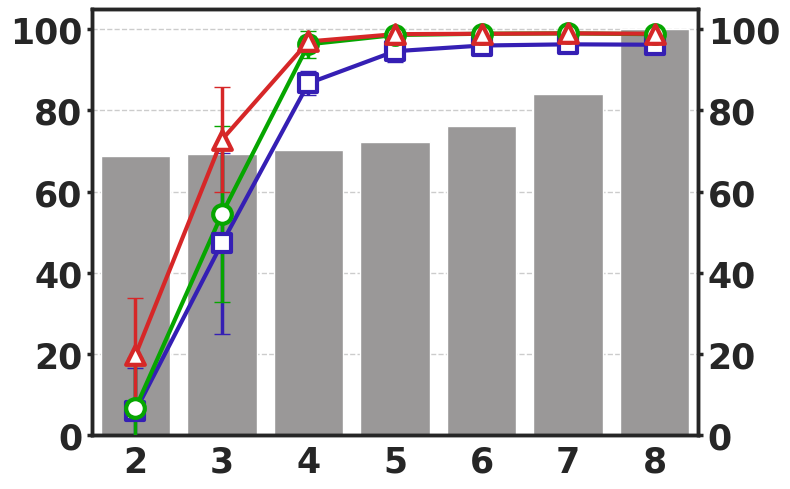

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            78.0              NaN             76.33                  NaN            NaN
   64  3.0            94.1             16.1             80.27                 3.95         4.0803
   64  4.0            95.8              1.7             84.22                 3.95         0.4308
   64  5.0            96.6              0.8             88.16                 3.95         0.2027
   64  6.0            96.1             -0.5             92.11                 3.95        -0.1267
   64  7.0            96.4              0.3             96.05                 3.95         0.0760
   64  8.0            96.3             -0.1            100.00                 3.95        -0.0253
  128  2.0            90.2              NaN             76.33                  NaN            NaN
  128  3.0            97.8              7.6             80.27                 3.95         1.9261
  128  4.0          

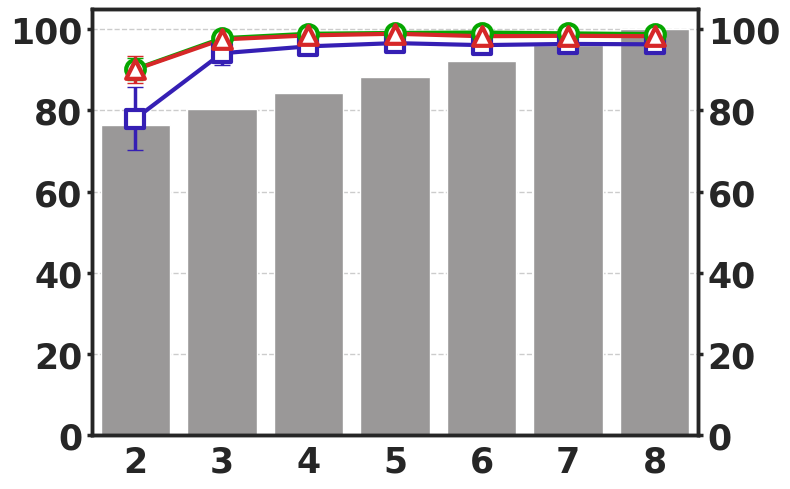

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            16.0              NaN             49.14                  NaN            NaN
   64  3.0            66.1             50.1             57.61                 8.48         5.9100
   64  4.0            90.3             24.2             66.09                 8.48         2.8547
   64  5.0            95.6              5.3             74.57                 8.48         0.6252
   64  6.0            97.1              1.5             83.05                 8.48         0.1769
   64  7.0            96.5             -0.6             91.52                 8.48        -0.0708
   64  8.0            96.2             -0.3            100.00                 8.48        -0.0354
  128  2.0             1.0              NaN             49.14                  NaN            NaN
  128  3.0            56.8             55.8             57.61                 8.48         6.5824
  128  4.0          

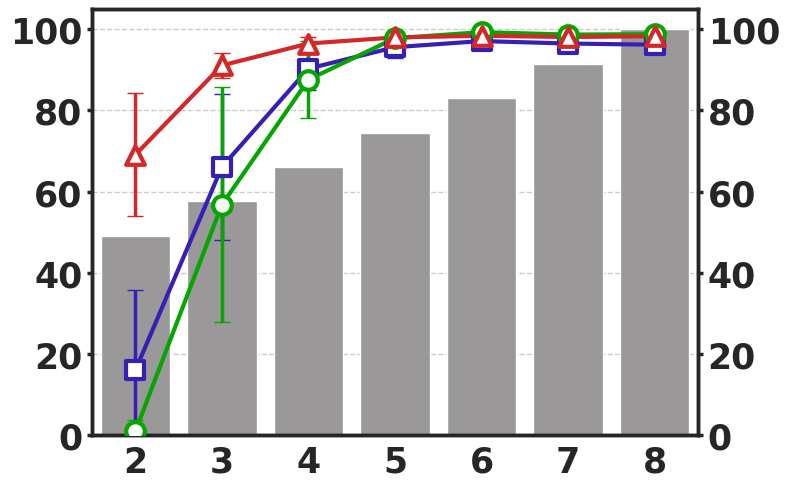

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            28.6              NaN             99.91                  NaN            NaN
   64  3.0            73.8             45.2             99.92                 0.02       2932.576
   64  4.0            89.3             15.5             99.94                 0.02       1005.640
   64  5.0            94.6              5.3             99.95                 0.02        343.864
   64  6.0            95.0              0.4             99.97                 0.02         25.952
   64  7.0            95.7              0.7             99.98                 0.02         45.416
   64  8.0            96.2              0.5            100.00                 0.02         32.440
  128  2.0            26.3              NaN             99.91                  NaN            NaN
  128  3.0            83.5             57.2             99.92                 0.02       3711.136
  128  4.0          

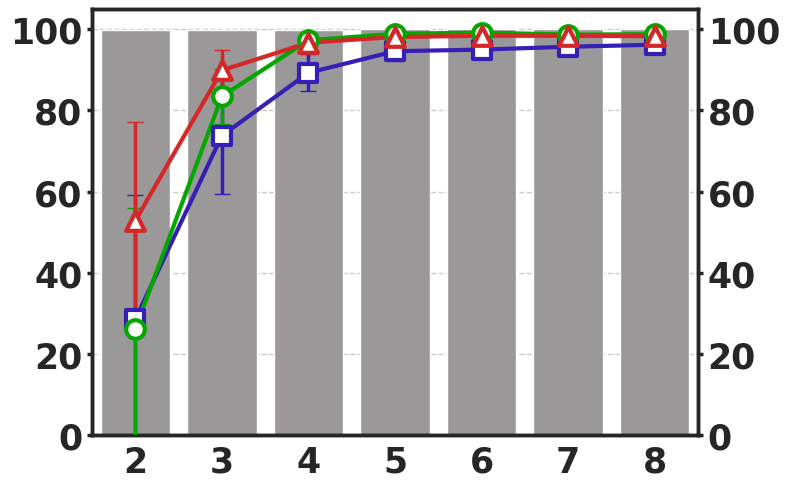

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            62.2              NaN             99.72                  NaN            NaN
   64  3.0            89.8             27.6             99.77                 0.05       596.8960
   64  4.0            95.8              6.0             99.82                 0.05       129.7600
   64  5.0            95.6             -0.2             99.86                 0.05        -4.3253
   64  6.0            96.8              1.2             99.91                 0.05        25.9520
   64  7.0            96.3             -0.5             99.95                 0.05       -10.8133
   64  8.0            96.3              0.0            100.00                 0.05         0.0000
  128  2.0            94.1              NaN             99.72                  NaN            NaN
  128  3.0            99.0              4.9             99.77                 0.05       105.9707
  128  4.0          

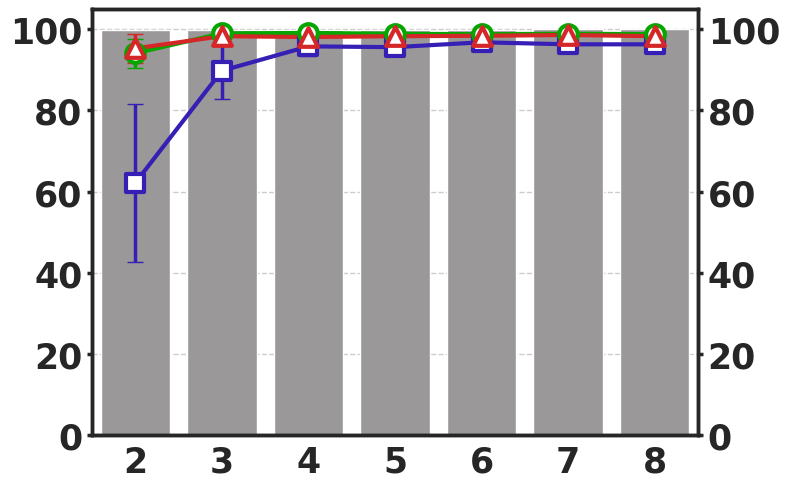

In [13]:
# CAM 
blocks=["CAM","LUT","Weight","SRAM","RRAM"]
for block in blocks:
    plot_quantization_results(block=block, bit_range=[2,3,4,5,6,7,8])

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
import re
import pandas as pd

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/quantize/LNN_standardization/proposal/6-5-6"
TOP_K = 10  # 上位k行で平均

results = []

for unit in units:
    pattern = f"{base_path}/unit{unit}.csv"
    files = sorted(glob.glob(pattern))

    for f in files:

        df = pd.read_csv(f)

        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
print(results_df)

   unit  mean_success  std_success
0    64         0.939     0.027264
1   128         0.987     0.009487
2   256         0.969     0.017920
